# **Animal Adoption Prediction**

## Summary

Animal adoption is a critical issue for shelters, as many animals experience prolonged stays or never find a permanent home. 
This study aims to build a classification model that predicts whether an animal will be adopted based on its attributes. 
Using data from the [Long Beach Animal Shelter](https://github.com/rfordatascience/tidytuesday/blob/main/data/2025/2025-03-04/readme.md), we will analyze key factors such as species, breed, age, health status, and intake type. 
Through exploratory data analysis and predictive modeling, we hope to identify patterns that influence adoption rates.
Our goal is to provide insights that can help shelters improve adoption strategies and increase successful placements.


## **Introduction**

### Background Information


Animal shelters play a crucial role in rehoming stray and surrendered animals. However, many animals face extended shelter stays, 
leading to overcrowding and resource constraints ([ASPCA, 2025](https://www.aspca.org/helping-people-pets/shelter-intake-and-surrender/pet-statistics?utm_source=chatgpt.com)). 

Recent studies indicate that **adoption rates vary significantly by species, breed, and medical condition** ([The Zebra, 2025](https://www.thezebra.com/resources/research/pet-adoption-statistics/?utm_source=chatgpt.com)). 
Understanding what factors influence adoption can help shelters make data-driven decisions to improve adoption rates. 

In recent years, data-driven approaches have been applied to predict adoption outcomes, allowing shelters to prioritize resources 
and create targeted adoption campaigns ([BMC Vet Research, 2020](https://bmcvetres.biomedcentral.com/articles/10.1186/s12917-020-02728-2?utm_source=chatgpt.com)). 
Previous studies have shown that characteristics such as species, age, breed, and health status 
can significantly impact adoption likelihood ([DrPress, 2021](https://drpress.org/ojs/index.php/HSET/article/view/28962?utm_source=chatgpt.com)). 
By leveraging machine learning techniques, we aim to develop a model that predicts 
whether an animal will be adopted based on its attributes.

### Problem Statement

Can we predict whether an animal will be adopted based on its attributes? 
This study aims to address this question using a classification model trained on animal shelter intake and outcome data. 
Specifically, we will classify each animal as either **adopted (Yes) or not adopted (No)** using key features such as species, 
age, breed, and medical conditions. 

By understanding which features are most important in predicting adoption, we can provide actionable insights to shelters 
to increase adoption rates and improve animal welfare.


### **Dataset Description**

The dataset used in this study comes from the **TidyTuesday project** and contains **animal intake and outcome records** from the **Long Beach Animal Shelter**. The dataset provides details on each animal’s characteristics, the reason for intake, and the outcome of their stay at the shelter.

This dataset is publicly available and can be accessed here:  
[Long Beach Animal Shelter Data](https://github.com/rfordatascience/tidytuesday/blob/main/data/2025/2025-03-04/readme.md).

#### **Key Variables**
Below are some of the key variables relevant to predicting adoption outcomes:

- **`animal_id`** → Unique identification number for each animal.  
- **`animal_name`** → Given name of the animal (if available).  
- **`animal_type`** → Type of animal (e.g., Dog, Cat).  
- **`primary_color`**, **`secondary_color`** → Animal’s primary and secondary colors.  
- **`sex`** → Altered sex status of the animal (e.g., Male/Neutered, Female/Spayed).  
- **`dob`** → Date of birth (if available).  
- **`intake_date`** → Date the animal was brought to the shelter.  
- **`intake_condition`** → Condition at intake (e.g., Healthy, Sick, Injured).  
- **`intake_type`** → Reason for intake (e.g., Stray, Owner Surrender, Adoption Return).  
- **`outcome_date`** → Date of the recorded outcome (e.g., adoption, euthanasia).  
- **`outcome_type`** → The final result for the animal (e.g., Adopted, Died, Euthanized, Transferred).  
- **`outcome_is_dead`** → Whether the animal was deceased at the time of outcome (`True/False`).  
- **`was_outcome_alive`** → Whether the animal was alive at outcome (`True/False`).  


#### **Identifying the Target Variable (`adopted`)**
Our project aims to **predict whether an animal is adopted**. However, the dataset does **not have a direct column named `adopted`**. Instead, we need to **derive** this outcome based on the `outcome_type` variable.

**Defining `adopted` as the target variable:**
- If **`outcome_type`** = `"Adopted"`, we define `adopted = Yes`.  
- If **`outcome_type`** is any other category (e.g., `"transferred"`, `"euthanized"`, `"return to owner"`), we define `adopted = No`.  

By structuring the problem in this way, we aim to develop a predictive model that can help shelters identify adoption trends and improve adoption strategies.


---

## **Methods & Results:**

In [2]:
install.packages("tidytuesdayR")


The downloaded binary packages are in
	/var/folders/pk/lf6l0f7j4sqg3_2178k28s080000gn/T//Rtmp8k0JQJ/downloaded_packages


In [4]:
# Load necessary libraries
library(readr)
library(dplyr)
library(caret)
library(tidyverse)
library(randomForest)

# Define data source URL
data_url <- "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2025/2025-03-04/longbeach.csv"

# Define the path to save the raw data
output_file <- "../data/raw/longbeach.csv"

# Ensure the `data/raw/` directory exists
if (!dir.exists("../data/raw")) {
  dir.create("../data/raw", recursive = TRUE)
}

# Download and save the dataset
download.file(data_url, destfile = output_file, mode = "wb")
print(paste("Data successfully downloaded and saved to", output_file))

# Read the dataset
longbeach <- read_csv(output_file)
head(longbeach)

[1] "Data successfully downloaded and saved to ../data/raw/longbeach.csv"


Rows: 29787 Columns: 22
-- Column specification --------------------------------------------------------
Delimiter: ","
chr  (15): animal_id, animal_name, animal_type, primary_color, secondary_col...
dbl   (2): latitude, longitude
lgl   (2): outcome_is_dead, was_outcome_alive
date  (3): dob, intake_date, outcome_date

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


animal_id,animal_name,animal_type,primary_color,secondary_color,sex,dob,intake_date,intake_condition,intake_type,...,outcome_date,crossing,jurisdiction,outcome_type,outcome_subtype,latitude,longitude,outcome_is_dead,was_outcome_alive,geopoint
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<date>,<date>,<chr>,<chr>,...,<date>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<lgl>,<lgl>,<chr>
A693708,*charlien,dog,white,NA,Female,2013-02-21,2023-02-20,ill mild,stray,...,2023-02-26,"[2600 BLK LONG BEACH BLVD, LONG BEACH CA, 90806",Long Beach,euthanasia,ill severe,33.80479,-118.1889,TRUE,FALSE,"33.8047935, -118.1889261"
A708149,NA,reptile,brown,green,Unknown,NA,2023-10-03,normal,stray,...,2023-10-03,"`600 BLK E HARCOURT, LB 90805",Long Beach,rescue,other resc,33.86800,-118.2009,FALSE,TRUE,"33.8679994, -118.2009307"
A638068,NA,bird,green,red,Unknown,NA,2020-01-01,injured severe,wildlife,...,2020-01-01,"0 BLK GRAND AVE, LONG BEACH, CA 90803",Long Beach,euthanasia,inj severe,33.76048,-118.1481,TRUE,FALSE,"33.7604783, -118.1480912"
A639310,NA,bird,white,gray,Unknown,NA,2020-02-02,ill severe,wildlife,...,2020-02-02,"0 BLK TEMPLE AVE, LONG BEACH, CA 90803",Long Beach,transfer,lbah,33.76246,-118.1597,FALSE,TRUE,"33.7624598, -118.1596777"
A618968,*morgan,cat,black,white,Female,2014-12-18,2018-12-18,injured severe,stray,...,2019-01-13,"0 BLK W ZANE ST, LONG BEACH, CA 90805",Long Beach,rescue,littlelion,33.84950,-118.1949,FALSE,TRUE,"33.8495009, -118.1949053"
A730385,*brandon,rabbit,black,white,Neutered,2023-04-19,2024-10-18,normal,stray,...,2024-11-15,00 AQUARIUM WAY LONG BEACH CA 90802,Long Beach,adoption,web,33.76399,-118.1944,FALSE,TRUE,"33.7639859, -118.1944096"


In [5]:
# Check missing values
colSums(is.na(longbeach))

animal_id       animal_name       animal_type     primary_color 
                0             12162                 0                 0 
  secondary_color               sex               dob       intake_date 
            15604                 0              3591                 0 
 intake_condition       intake_type    intake_subtype reason_for_intake 
                0                 0               390             27784 
     outcome_date          crossing      jurisdiction      outcome_type 
              177                 0                 1               187 
  outcome_subtype          latitude         longitude   outcome_is_dead 
             3386                 0                 0                 0 
was_outcome_alive          geopoint 
                0                 0

In [6]:
# Remove rows where outcome_type is missing (since it's our target variable)
longbeach_cleaned <- longbeach %>%
  filter(!is.na(outcome_type))

# # Replace blank values in `animal_name` with "Unknown"
# longbeach_cleaned$animal_name[longbeach_cleaned$animal_name == ""] <- "Unknown"

# # Replace blank values in `secondary_color` with NA
# longbeach_cleaned$secondary_color[longbeach_cleaned$secondary_color == ""] <- NA

# Remove rows with missing DOB
longbeach_cleaned <- longbeach_cleaned %>%
  filter(!is.na(dob))


In [7]:
# View unique values and their counts in outcome_type
outcome_summary <- longbeach_cleaned %>%
  count(outcome_type, sort = TRUE)

print(outcome_summary)


# A tibble: 18 x 2
   outcome_type                n
   <chr>                   <int>
 1 adoption                 6156
 2 rescue                   5911
 3 euthanasia               4148
 4 transfer                 4128
 5 return to owner          3107
 6 shelter, neuter, return   896
 7 died                      585
 8 community cat             334
 9 foster to adopt           164
10 return to wild habitat    146
11 transport                 133
12 homefirst                  86
13 missing                    54
14 return to rescue           46
15 disposal                   45
16 trap, neuter, release      35
17 duplicate                  27
18 foster                     10


To transform this dataset into a **binary classification problem**, we define the target variable `adopted` as:

- **`adopted = "Yes"`** → If `outcome_type` is `"adoption"` or `"foster to adopt"`.  
- **`adopted = "No"`** → If `outcome_type` is any other category (e.g., `"euthanasia"`, `"transfer"`, `"return to owner"`).  

This classification ensures that our model specifically focuses on **predicting whether an animal finds a permanent home** rather than just leaving the shelter.


In [8]:
# Create the adopted column
longbeach_cleaned <- longbeach_cleaned %>%
  mutate(adopted = ifelse(outcome_type %in% c("adoption", "foster to adopt"), "Yes", "No"))

# Check the new column
table(longbeach_cleaned$adopted)


   No   Yes 
19691  6320 

#### Brief Summary for Data Before Moving to EDA Visualization

In [9]:
# View summary statistics of the dataset
summary(longbeach_cleaned)

# Count distribution of adoption outcomes
table(longbeach_cleaned$adopted)

  animal_id         animal_name        animal_type        primary_color     
 Length:26011       Length:26011       Length:26011       Length:26011      
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
                                                                            
                                                                            
                                                                            
 secondary_color        sex                 dob            
 Length:26011       Length:26011       Min.   :1993-05-28  
 Class :character   Class :character   1st Qu.:2016-07-01  
 Mode  :character   Mode  :character   Median :2018-10-15  
                                       Mean   :2018-07-30  
                                       3rd Qu.:2022-01-12  
                                       Max.   :2031-03-30  
  intake_date         intake_condition   


   No   Yes 
19691  6320 

Here's the initial summary of the dataset to understand its structure and distributions.

- **Key Findings from the Summary**
1. **Dataset Overview**  
   - The dataset contains **26,011 records** after cleaning.  
   - Key variables include categorical attributes (`animal_type`, `primary_color`, `sex`) and numerical attributes (`dob`, `intake_date`, `latitude`, `longitude`).

2. **Missing Values**  
   - **`dob` (Date of Birth)** has missing values, which might affect age-based analysis, so already dropped these rows.
   - **`reason_for_intake`** is mostly missing (**27,784 missing values**) and may not be useful for modeling.  
   - **`outcome_date`** has **177 missing values**, which we may need to address.

3. **Date-Based Observations**  
   - **`dob` ranges from 1993 to 2031**, indicating possible incorrect data points (future dates need to be cleaned).  
   - **`intake_date` and `outcome_date`** range from **2017 to 2024**, covering a long period of adoption records.

4. **Geographical Data**  
   - **Latitude and Longitude** values indicate the shelter's location but may not be useful for adoption predictions.

---
The next step is to **visualize key trends** in the dataset to understand adoption patterns.
Do EDA helps select the predictor variables for modeling, also check if there's any outliers or data quality issues?



- - **`dob` ranges from 1993 to 2031**, indicating possible incorrect data points (future dates need to be cleaned).  

In [10]:
# Remove future dates
longbeach_cleaned <- longbeach_cleaned %>%
  filter(as.Date(dob) <= as.Date("2024-12-31"))


Warning message:
"The dot-dot notation (`..count..`) was deprecated in ggplot2 3.4.0.
i Please use `after_stat(count)` instead."


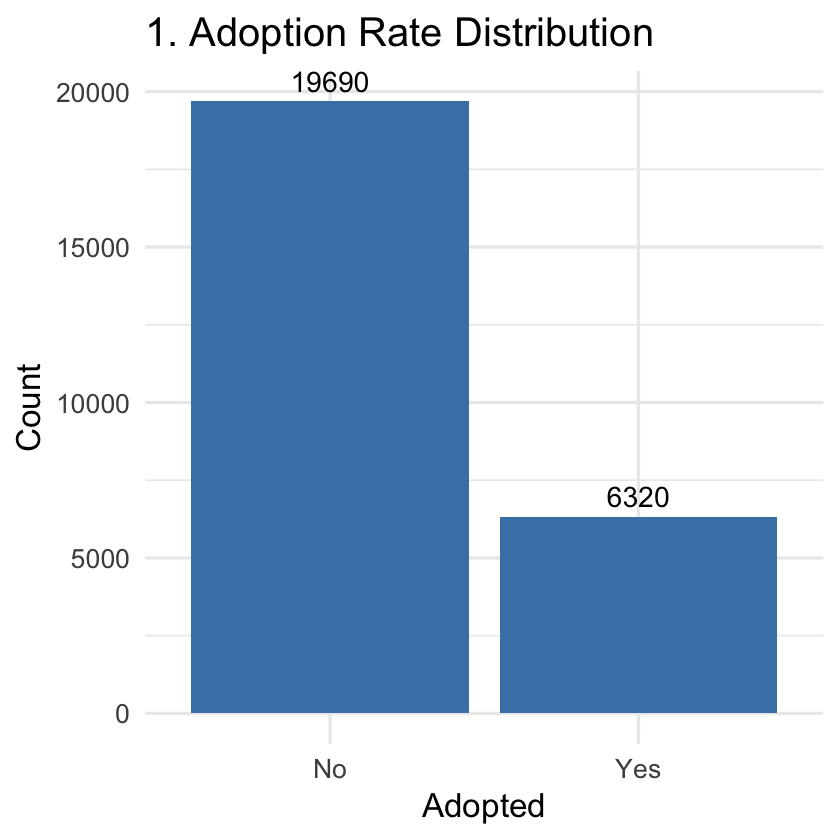

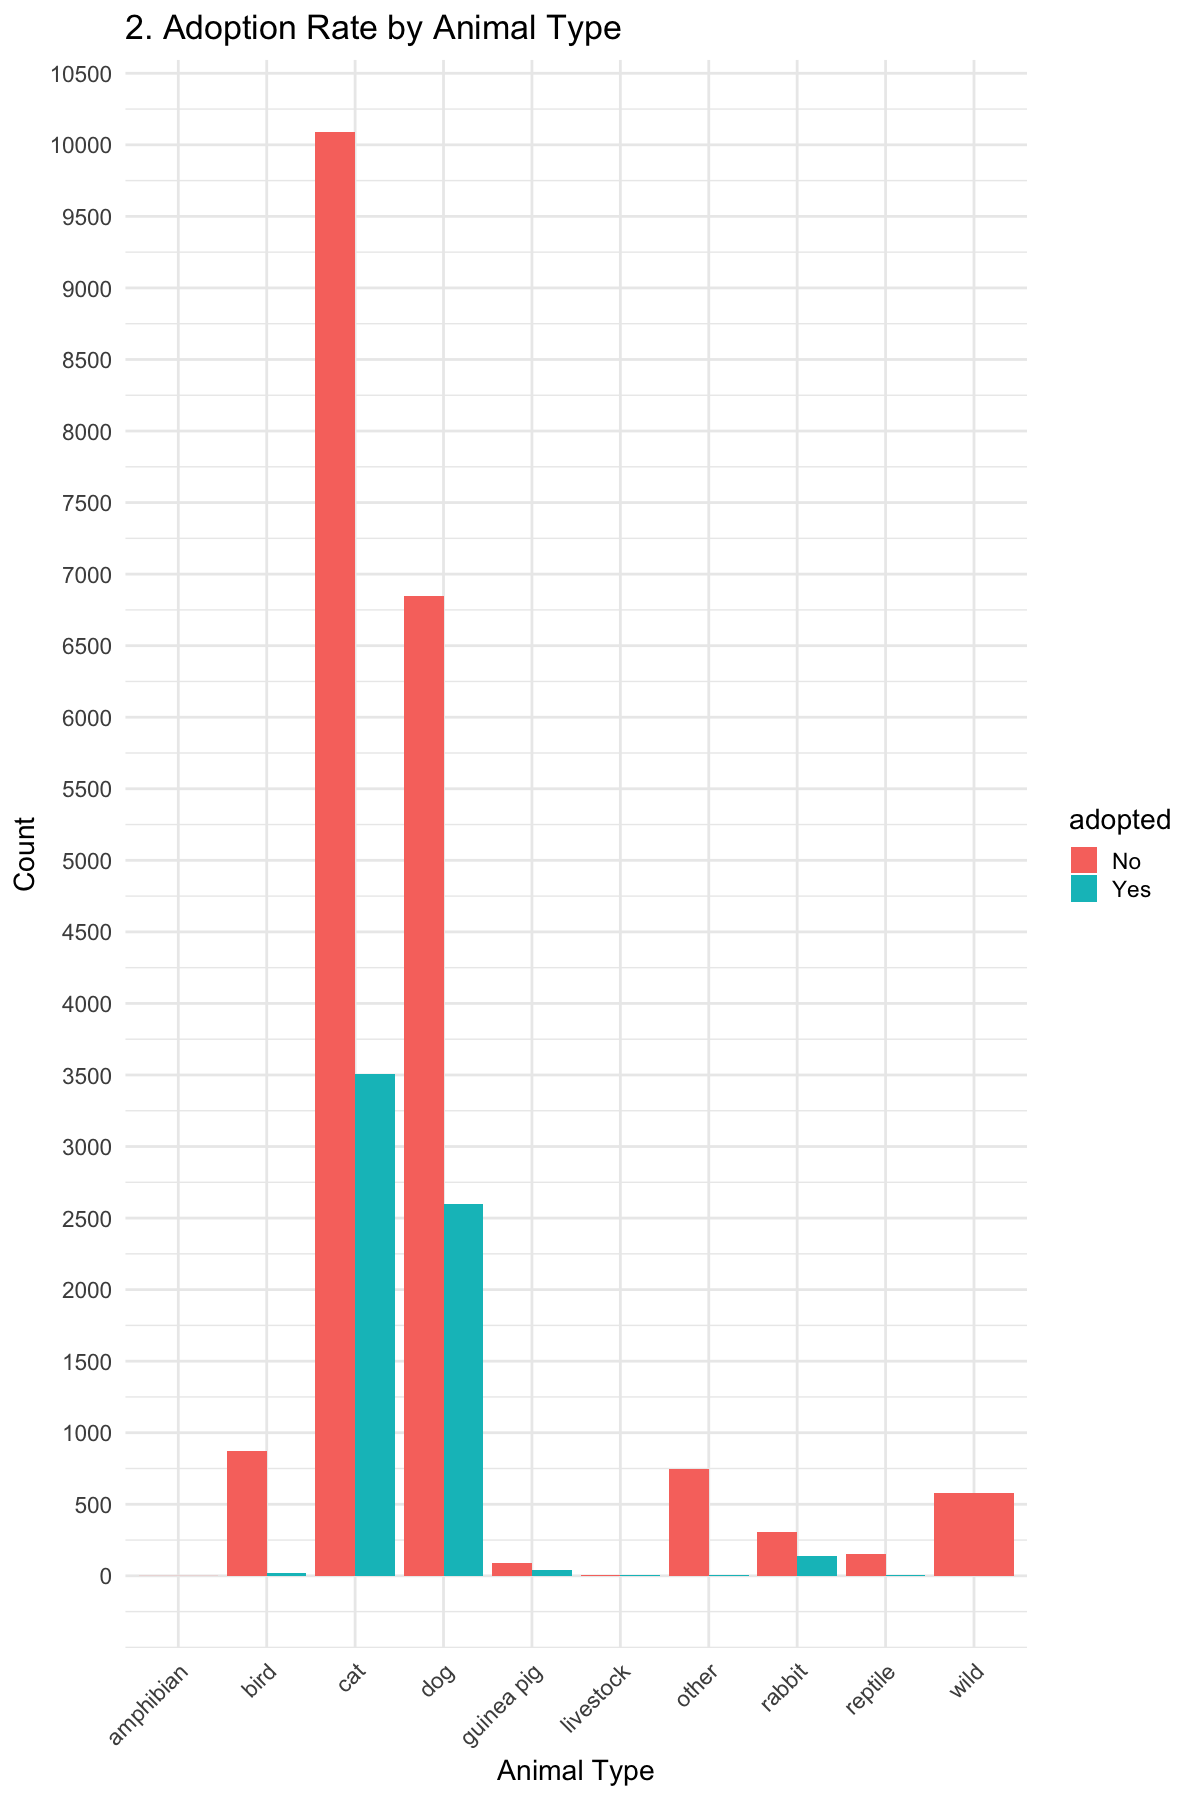

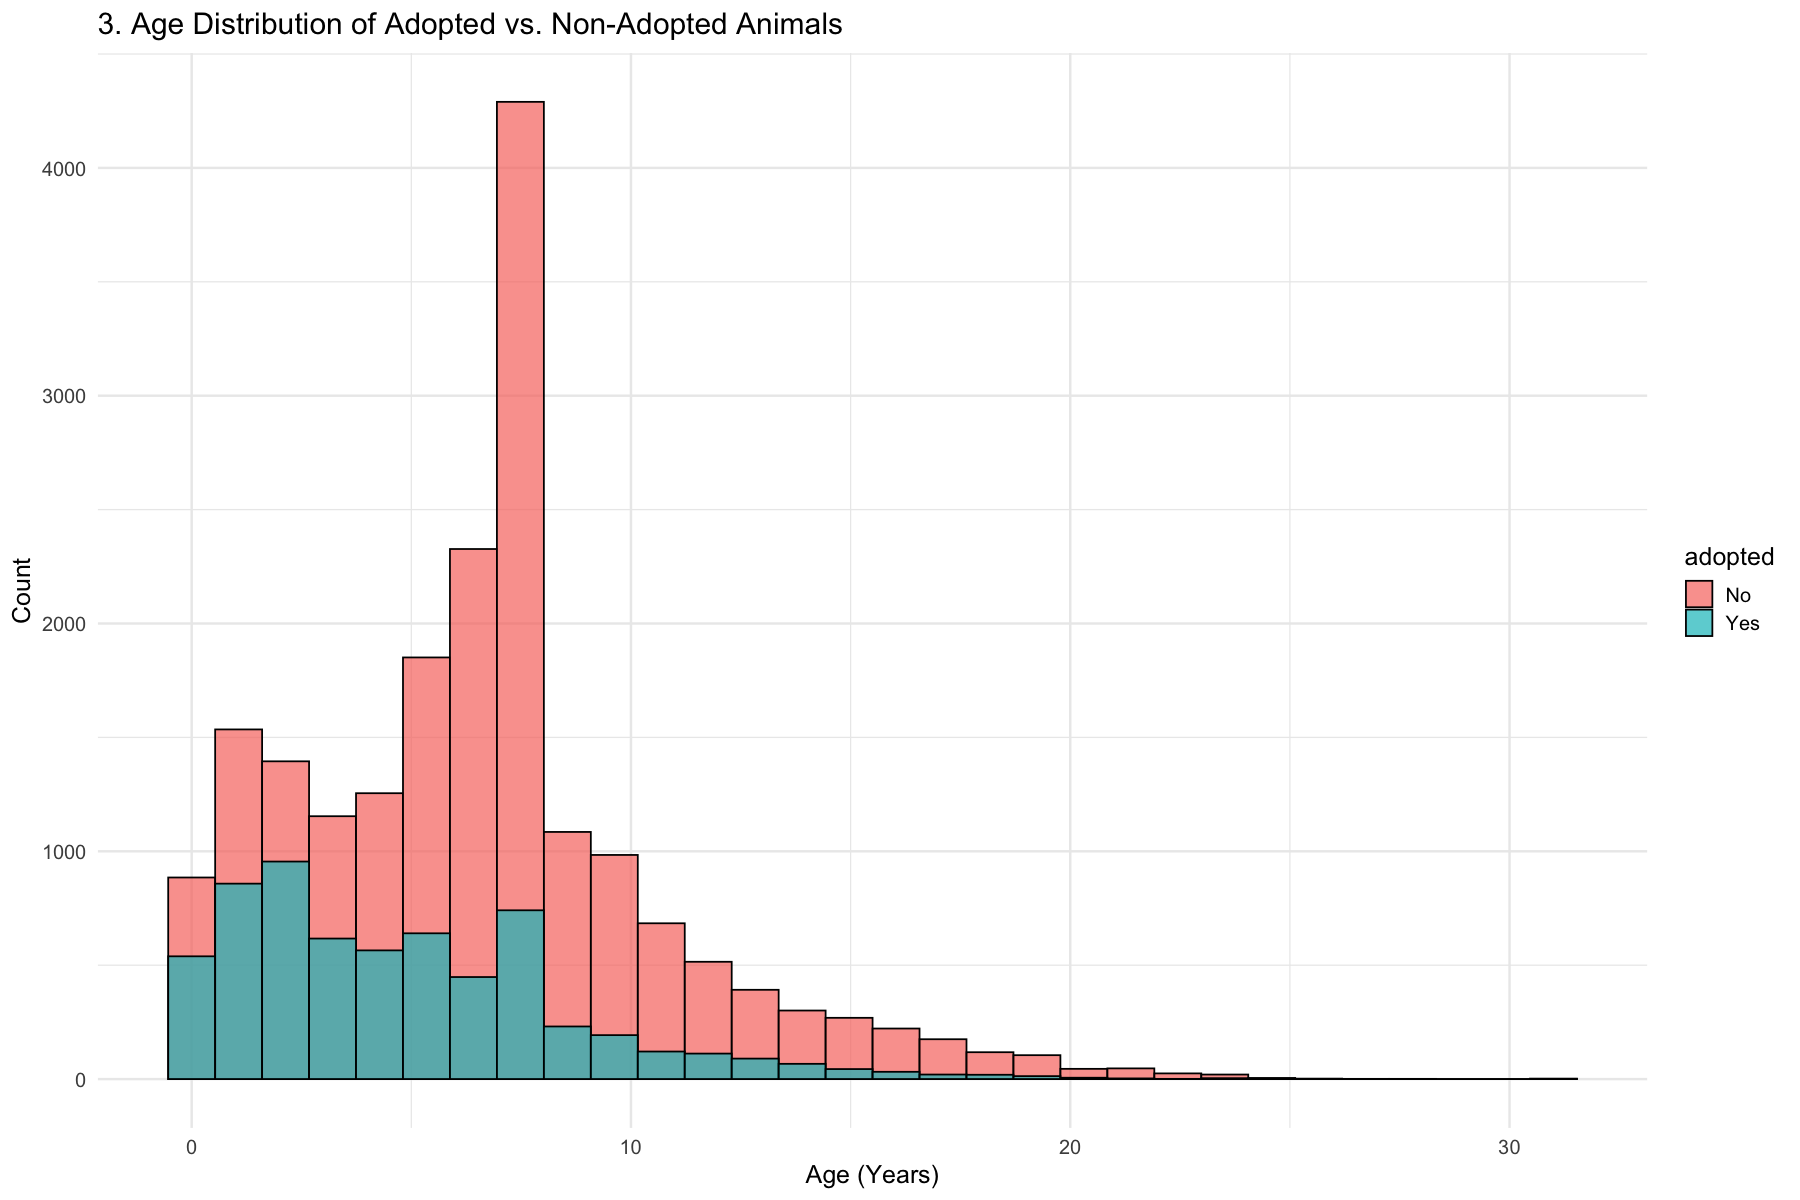

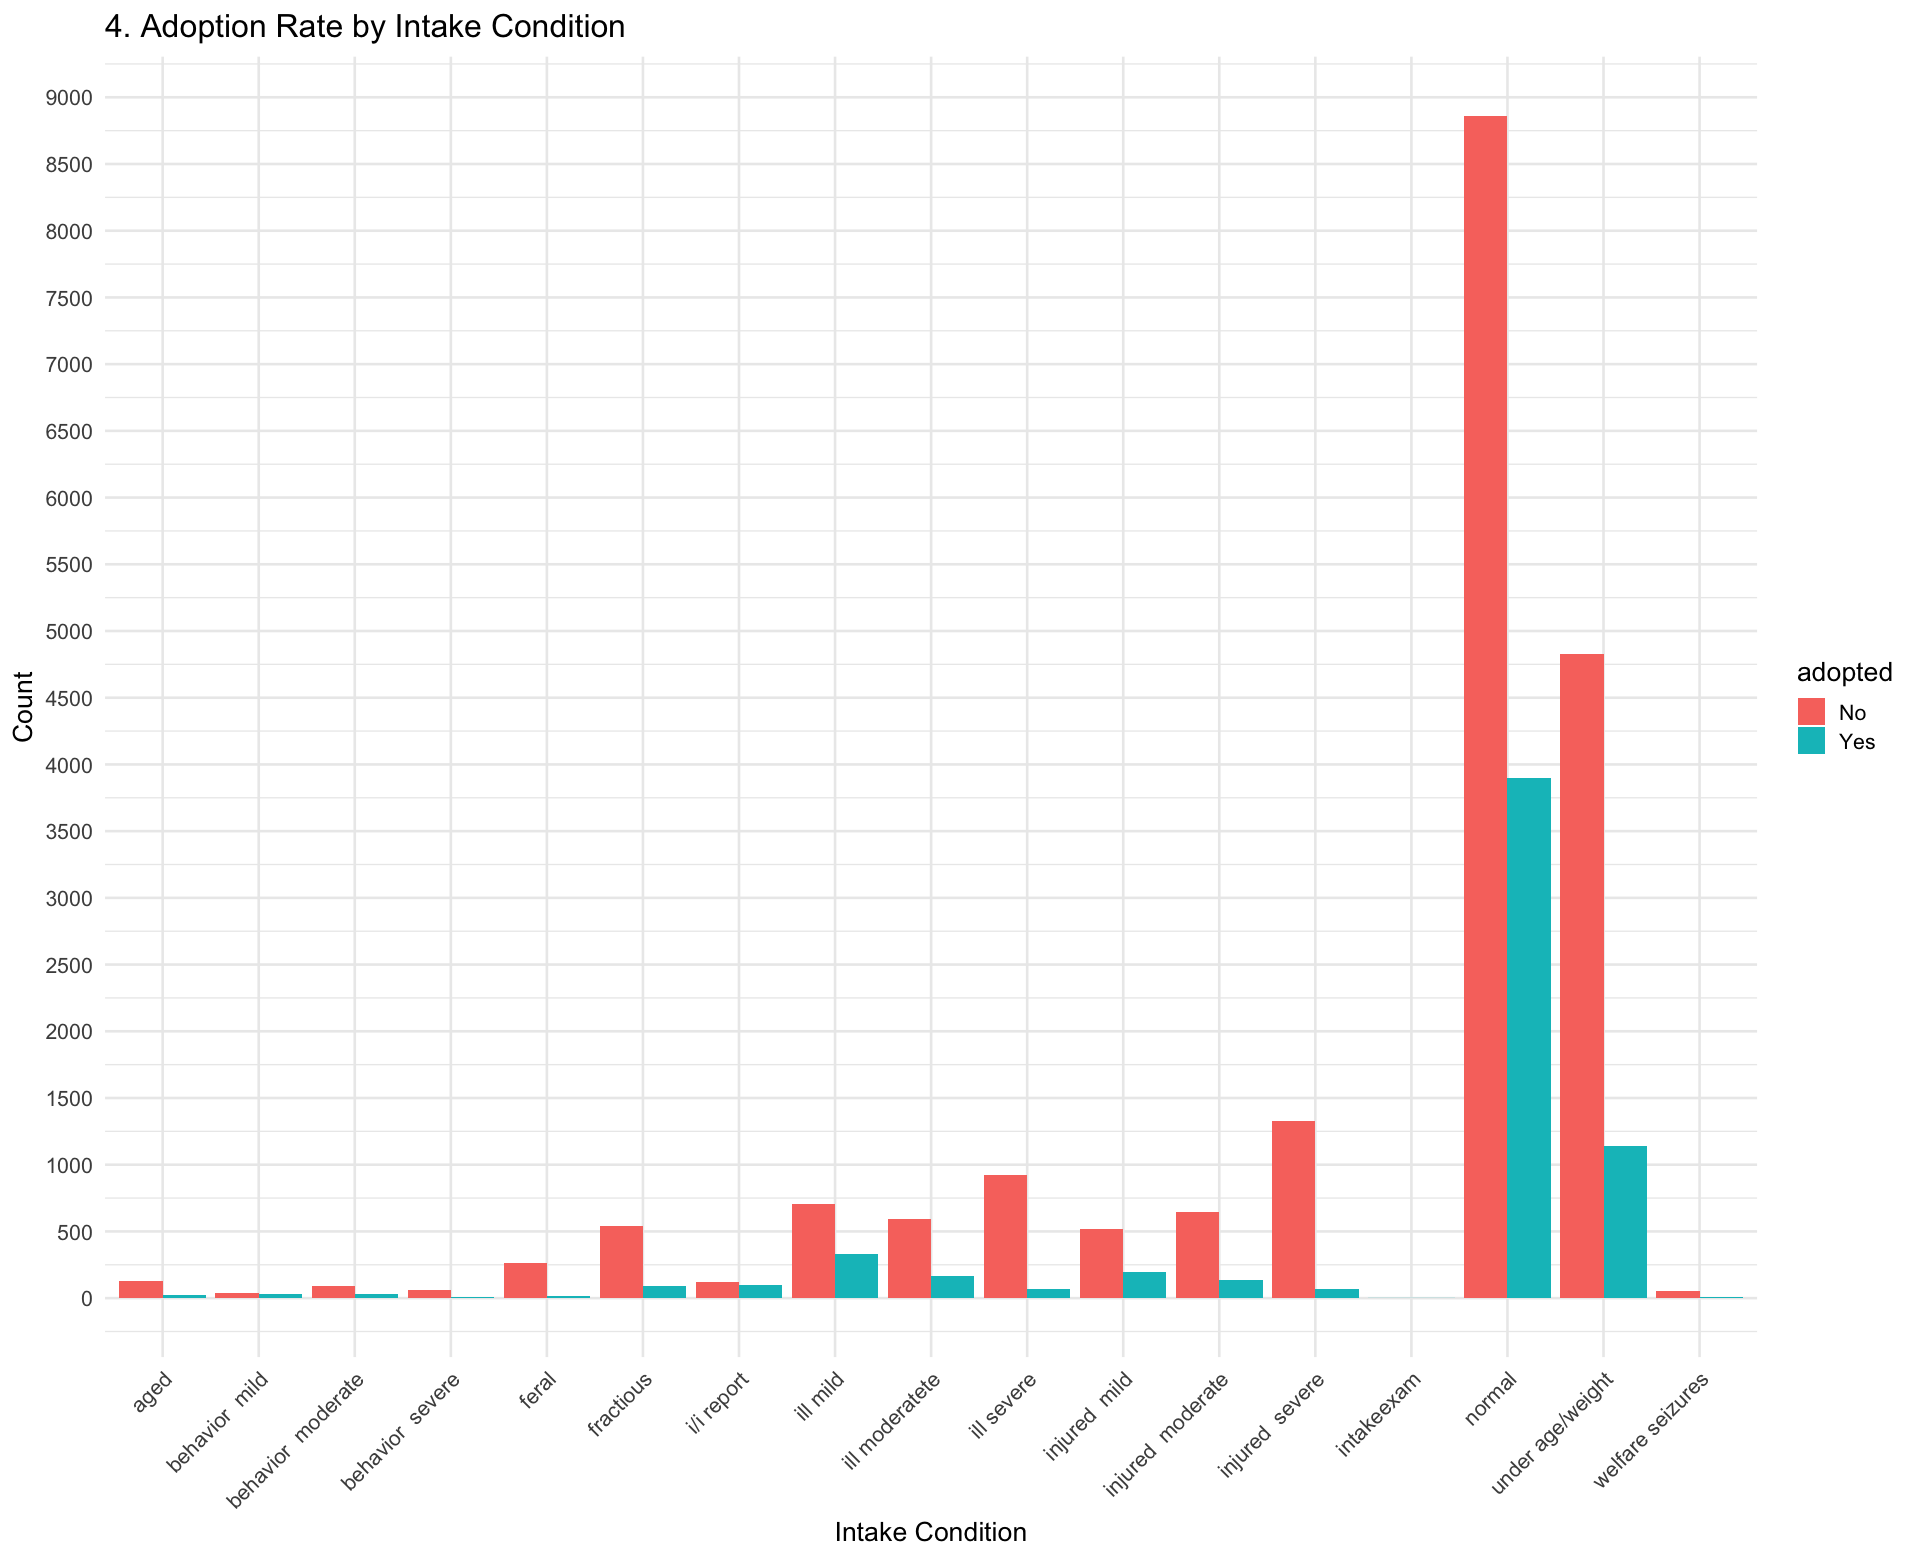

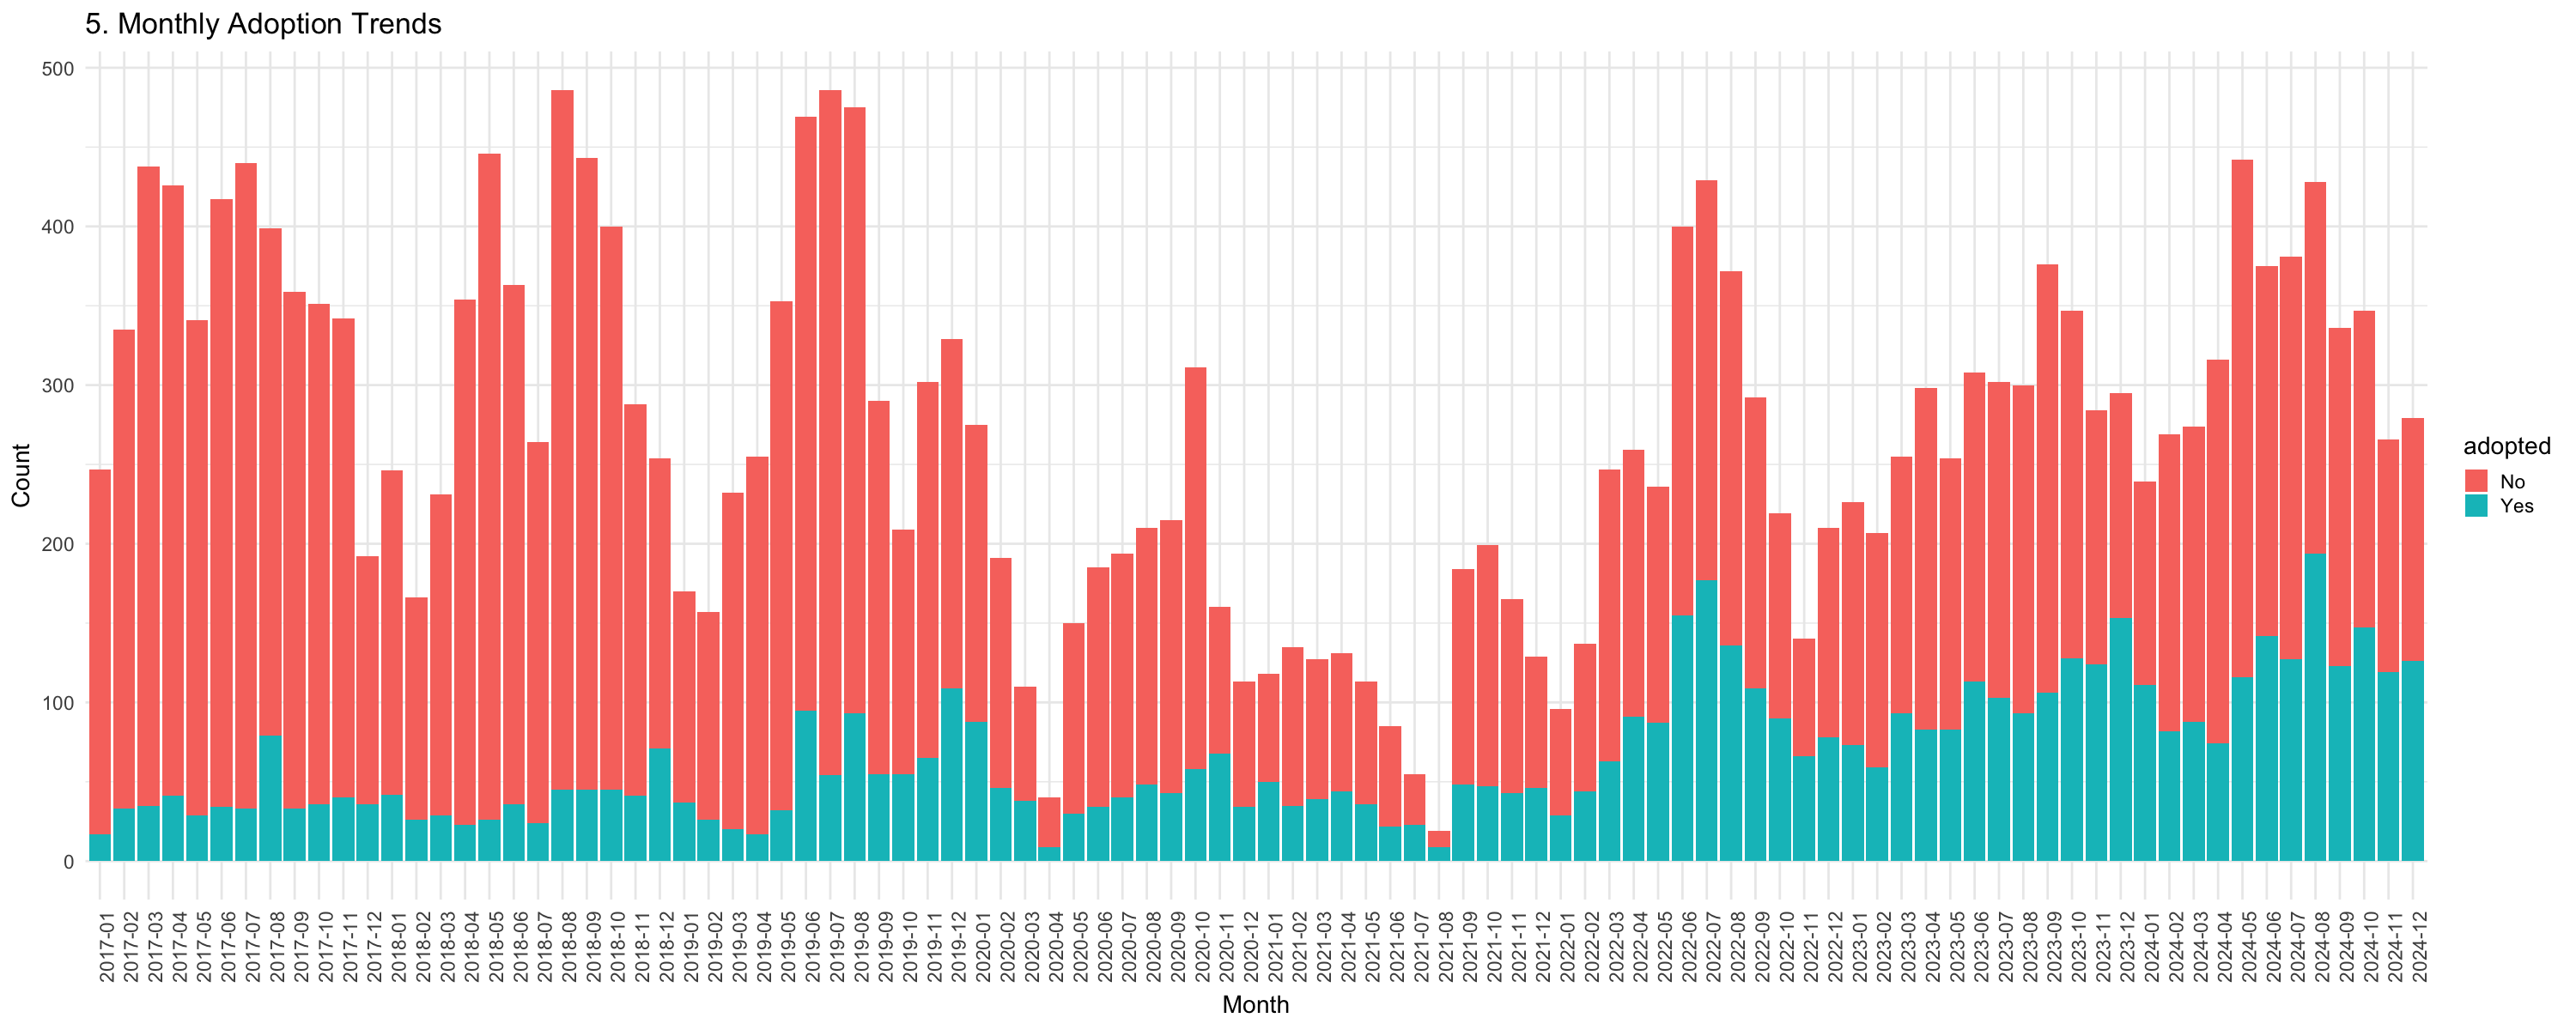

In [11]:
library(ggplot2)


# 1️. Adoption Rate Distribution
options(repr.plot.width = 7, repr.plot.height = 7) 
ggplot(longbeach_cleaned, aes(x = adopted)) +
  geom_bar(fill = "steelblue") +
  geom_text(stat='count', aes(label=..count..), vjust=-0.5, size=6) +
  labs(title = "1. Adoption Rate Distribution", x = "Adopted", y = "Count") +
  theme_minimal(base_size = 20)



# 2. Adoption Rate by Animal Type
options(repr.plot.width = 10, repr.plot.height = 15) 
ggplot(longbeach_cleaned, aes(x = animal_type, fill = adopted)) +
  geom_bar(position = "dodge") +
  labs(title = "2. Adoption Rate by Animal Type", x = "Animal Type", y = "Count") + 
  theme_minimal(base_size = 17) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  scale_y_continuous(breaks = seq(0, max(table(longbeach_cleaned$animal_type), na.rm = TRUE), by = 500))

# 3. Age Distribution (Convert DOB to Age)
options(repr.plot.width = 15, repr.plot.height = 10) 
longbeach_cleaned$age <- as.numeric(difftime(Sys.Date(), as.Date(longbeach_cleaned$dob, format="%Y-%m-%d"), units="days")) / 365
# Convert Age to Integer
longbeach_cleaned$age <- as.integer(longbeach_cleaned$age)

ggplot(longbeach_cleaned, aes(x = age, fill = adopted)) +
  geom_histogram(bins = 30, alpha = 0.7, position = "identity", color = "black") +
  labs(title = "3. Age Distribution of Adopted vs. Non-Adopted Animals", x = "Age (Years)", y = "Count") + 
  theme_minimal(base_size = 15)

# 4. Adoption Rate by Intake Condition
options(repr.plot.width = 16, repr.plot.height = 13)
ggplot(longbeach_cleaned, aes(x = intake_condition, fill = adopted)) +
  geom_bar(position = "dodge") +
  labs(title = "4. Adoption Rate by Intake Condition", x = "Intake Condition", y = "Count") +
  theme_minimal(base_size = 16) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  scale_y_continuous(breaks = seq(0, max(table(longbeach_cleaned$animal_type), na.rm = TRUE), by = 500))
  

# 5. Monthly Adoption Trends
longbeach_cleaned$month <- format(as.Date(longbeach_cleaned$outcome_date, format="%Y-%m-%d"), "%Y-%m")
options(repr.plot.width = 25, repr.plot.height = 10)
ggplot(longbeach_cleaned, aes(x = month, fill = adopted)) +
  geom_bar() +
  labs(title = "5. Monthly Adoption Trends", x = "Month", y = "Count") +
  theme_minimal(base_size = 17) +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))

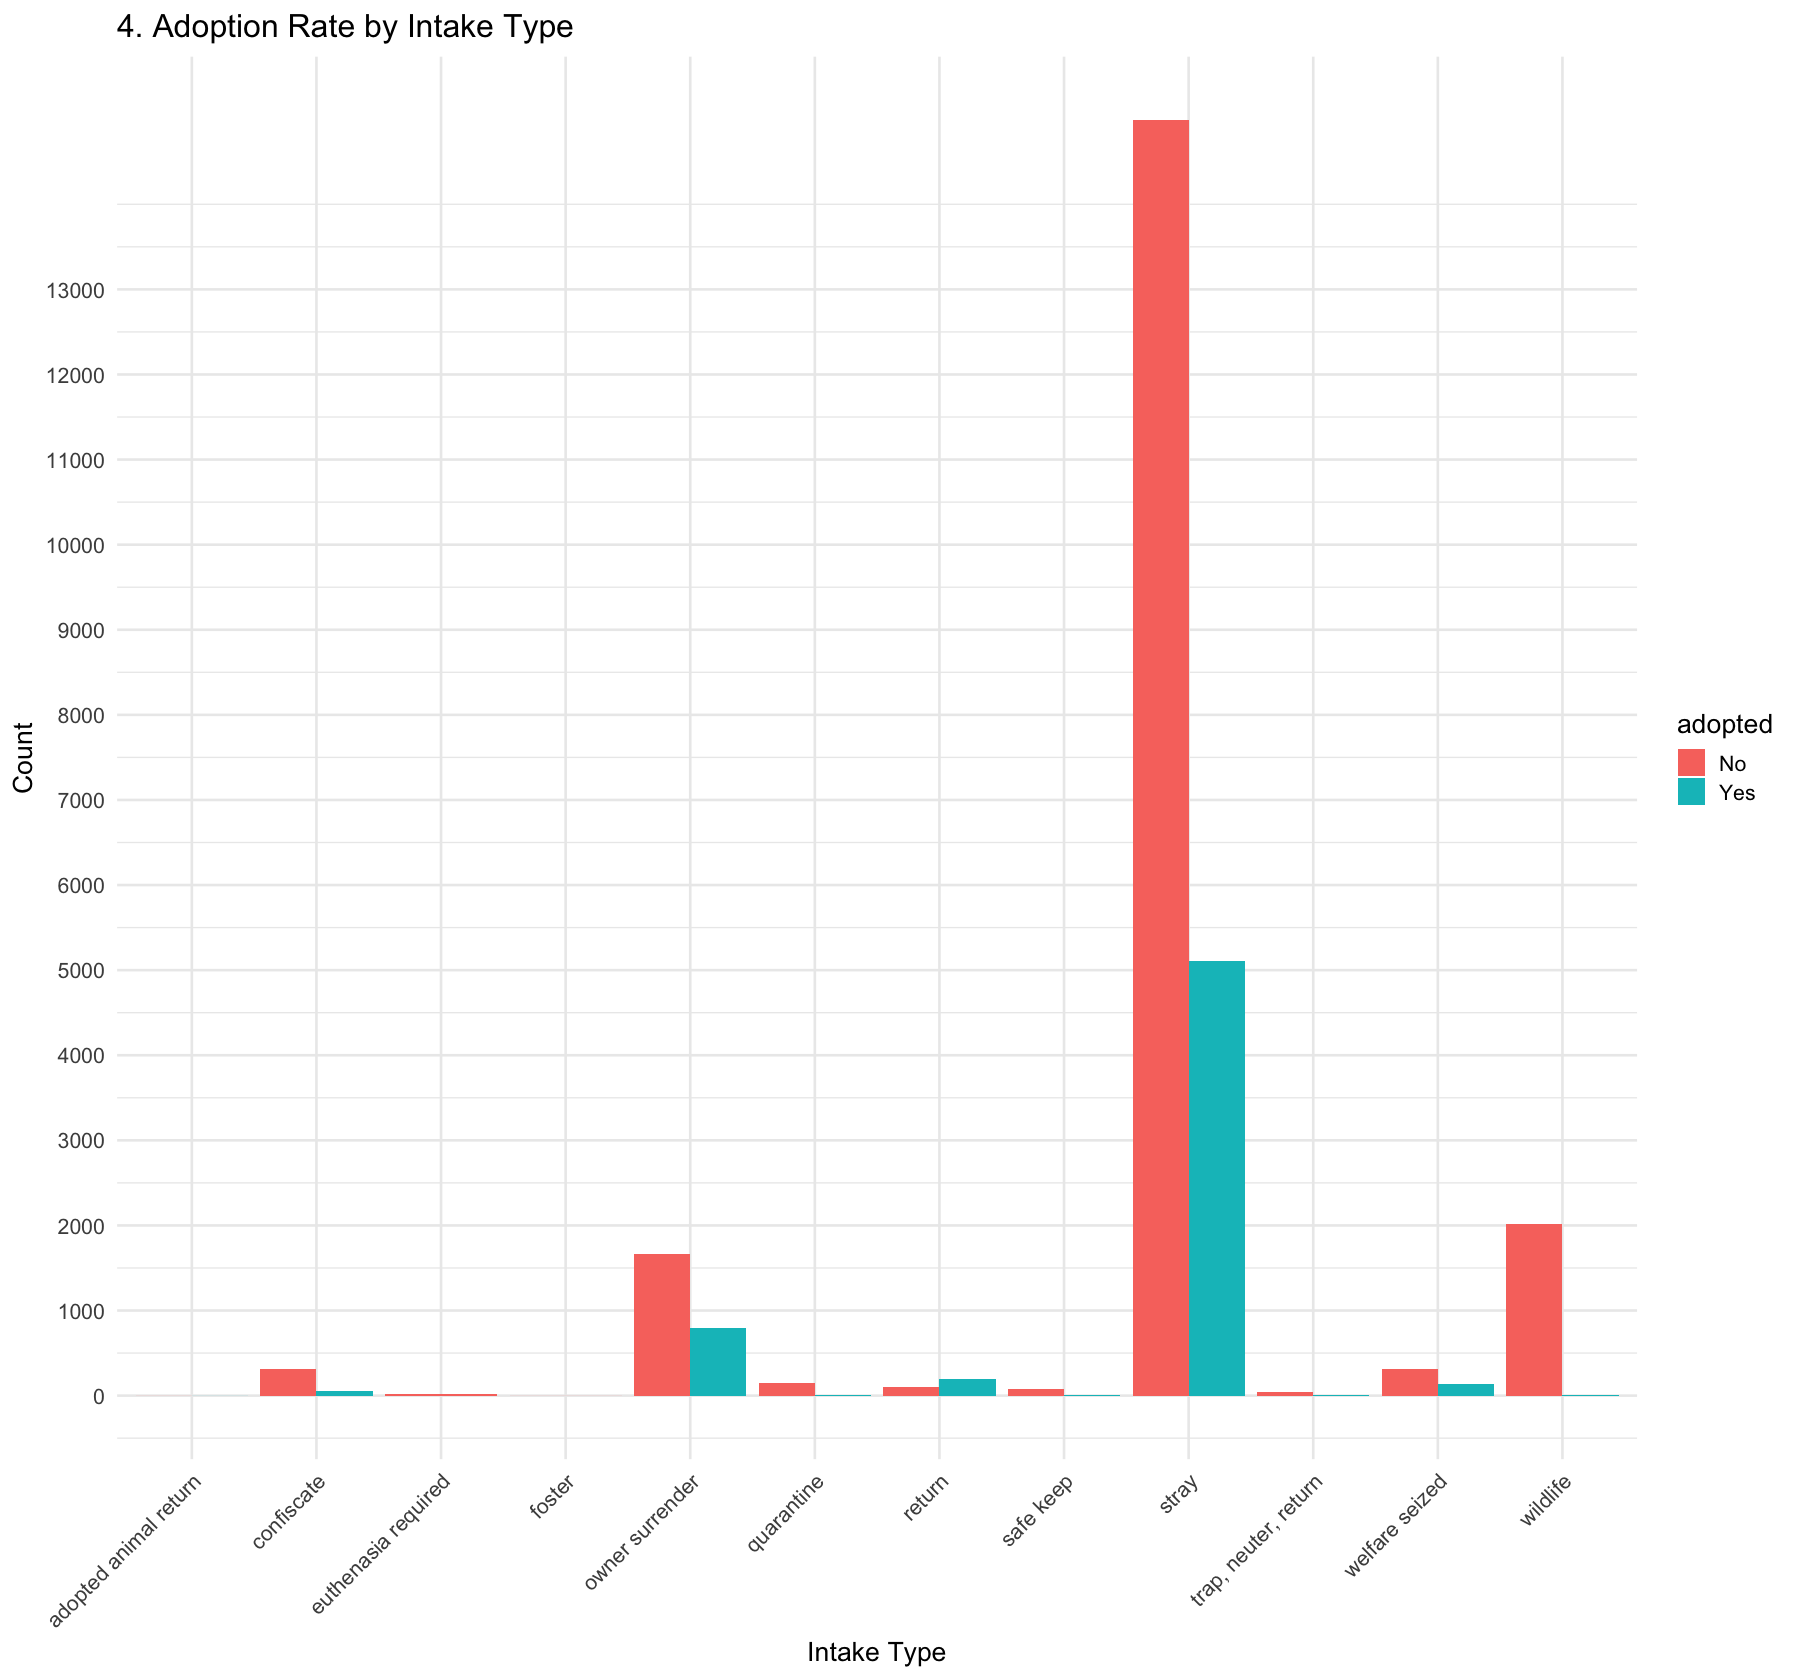

In [13]:
# 6. Adoption Rate by Intake Type

options(repr.plot.width = 15, repr.plot.height = 14)
ggplot(longbeach_cleaned, aes(x = intake_type, fill = adopted)) +
  geom_bar(position = "dodge") +
  labs(title = "4. Adoption Rate by Intake Type", x = "Intake Type", y = "Count") +
  theme_minimal(base_size = 16) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  scale_y_continuous(breaks = seq(0, max(table(longbeach_cleaned$animal_type), na.rm = TRUE), by = 1000))

## **Exploratory Data Analysis (EDA) - Key Findings**

**1. Adoption Rate Distribution**

**Observation:**
- A significant class imbalance: far more animals are **not adopted** than adopted.
- This suggests that we may need techniques like **balancing the dataset** or **adjusting the model threshold**.

**Action:**
- Consider using **class balancing techniques** (oversampling "Yes" cases or undersampling "No" cases) if needed.


**2. Adoption Rate by Animal Type**

**Observation:**
- **Dogs and cats** are the most commonly available animals.
- **Dogs have a higher adoption rate than cats**.
- Other animal types (e.g., birds, rabbits, reptiles) have significantly **lower adoption rates**.

**Action:**
- **Include `animal_type` as a key predictor** in your model.
- Consider **grouping rare animal types** into an `"Other"` category for better generalization.

**3. Adoption Rate by Intake Condition**

**Observation:**
- **Healthy animals ("normal") are adopted most frequently**.
- Animals with **injuries or severe conditions** are less likely to be adopted.
- **"Underage/weight"** animals have a moderate adoption rate.

**Action:**
- **Include `intake_condition` as a predictor.**
- Consider **grouping rare conditions** into broader categories.


**4. Monthly Adoption Trends**
**Observation:**
- Adoption rates **fluctuate significantly by month**.
- Some seasonal trends might be present (**e.g., more adoptions in summer/holiday months**).

**Action:**
- If the trend is strong, we can **extract month/season features** for modeling.


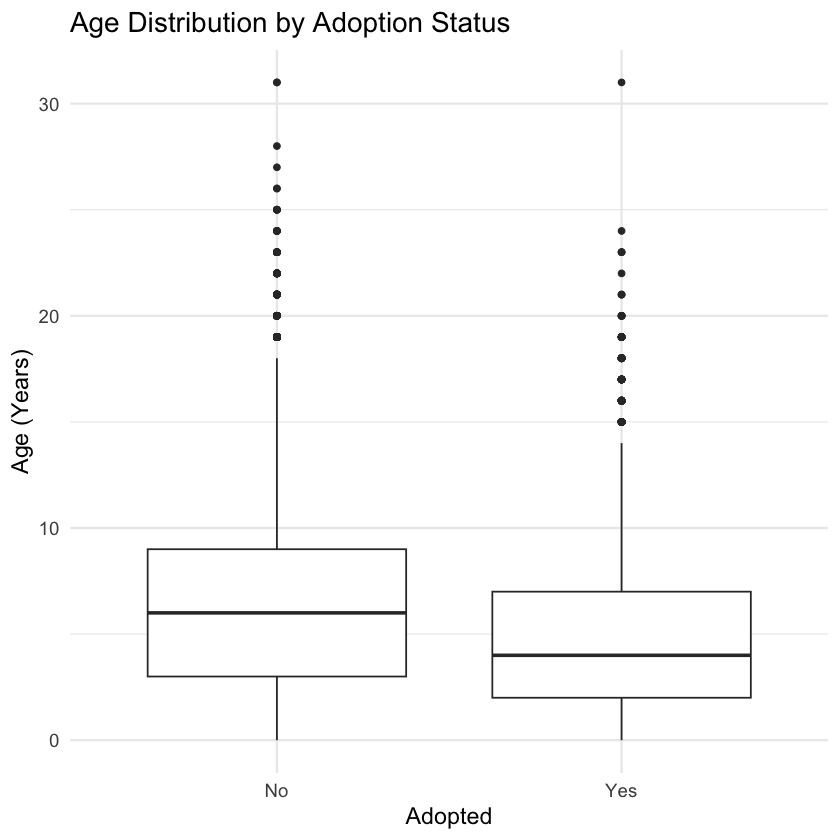

In [35]:
ggplot(longbeach_cleaned, aes(y = age, x = adopted)) +
  geom_boxplot() +
  labs(title = "Age Distribution by Adoption Status", x = "Adopted", y = "Age (Years)") +
  theme_minimal(base_size = 14)


#### Boxplot Analysis: 

Key Observations:
- Outliers Exist,there are many cases above 30 years.
- This suggests possible incorrect data entries (since most shelter animals don't reach 30+ years).

Decision: Remove age > 30


In [36]:
# Remove unrealistic ages (age > 30)
longbeach_cleaned <- longbeach_cleaned %>%
  filter(age <= 30)

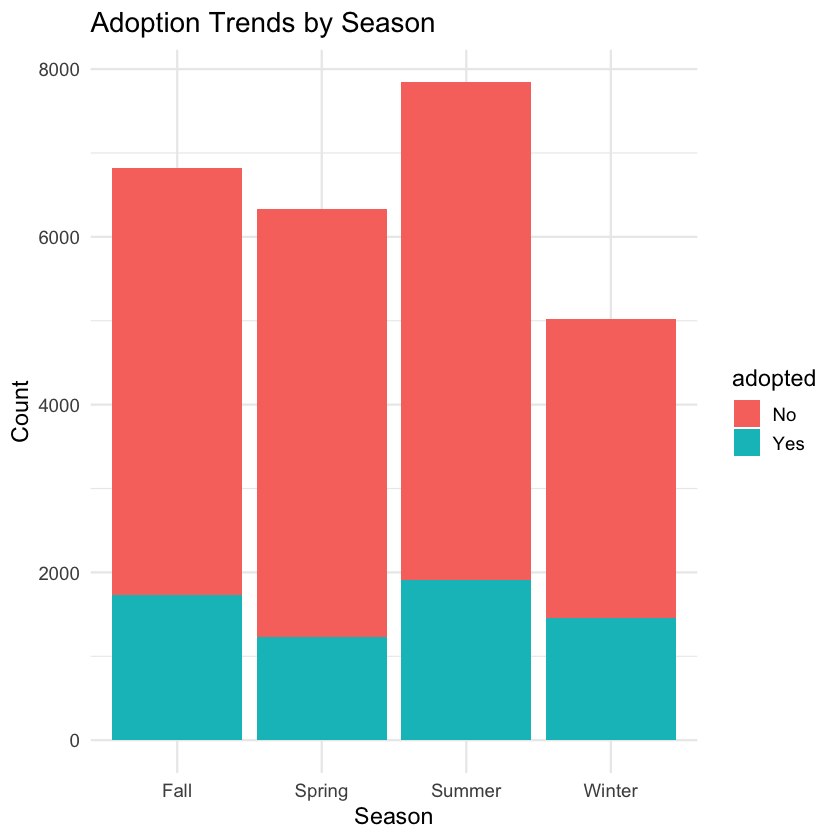

In [37]:
# Ensure `month` is extracted correctly
longbeach_cleaned <- longbeach_cleaned %>%
  mutate(month = format(as.Date(outcome_date, format="%Y-%m-%d"), "%m"))

# Create a new season column
longbeach_cleaned <- longbeach_cleaned %>%
  mutate(season = case_when(
    month %in% c("12", "01", "02") ~ "Winter",
    month %in% c("03", "04", "05") ~ "Spring",
    month %in% c("06", "07", "08") ~ "Summer",
    month %in% c("09", "10", "11") ~ "Fall",
    TRUE ~ "Unknown"
  ))

# Re-run the plot
ggplot(longbeach_cleaned, aes(x = season, fill = adopted)) +
  geom_bar() +
  labs(title = "Adoption Trends by Season", x = "Season", y = "Count") +
  theme_minimal(base_size = 14)



#### Seasonal Trends:

Observations: 
- Adoption Rates Are Fairly Consistent
- There are slight increases in adoption during summer.
- Winter has the lowest adoption rates.

Decision: Use season as a Feature.
*It might not be a strong predictor, but it could contribute to minor improvements.*


In [38]:
# Keep season as a categorical feature
longbeach_cleaned$season <- factor(longbeach_cleaned$season, levels = c("Spring", "Summer", "Fall", "Winter"))

In [39]:
# Count frequency of each animal type
animal_counts <- longbeach_cleaned %>%
  count(animal_type, sort = TRUE)

# Count frequency of each intake condition
intake_counts <- longbeach_cleaned %>%
  count(intake_condition, sort = TRUE)

print(animal_counts)
print(intake_counts)


# A tibble: 10 x 2
   animal_type     n
   <chr>       <int>
 1 cat         13596
 2 dog          9446
 3 bird          888
 4 other         755
 5 wild          581
 6 rabbit        443
 7 reptile       156
 8 guinea pig    131
 9 livestock      10
10 amphibian       1
# A tibble: 17 x 2
   intake_condition       n
   <chr>              <int>
 1 normal             12759
 2 under age/weight    5963
 3 injured  severe     1393
 4 ill mild            1040
 5 ill severe           991
 6 injured  moderate    780
 7 ill moderatete       759
 8 injured  mild        710
 9 fractious            634
10 feral                278
11 i/i report           224
12 aged                 155
13 behavior  moderate   124
14 behavior  mild        68
15 behavior  severe      68
16 welfare seizures      60
17 intakeexam             1


### Group the rare categories after checking the frequency:

**Animal type:**
- Categories with < 200 cases → "Other"
- New "Other" category: "Reptile", "Guinea Pig", "Livestock", "Amphibian"

**Intake Condiion:**
- Categories with < 200 cases → "Other"
- New "Other" category: "Aged", "Behavior Moderate", "Behavior Mild", "Behavior Severe", "Welfare Seizures", "Intake Exam"


In [40]:
# Define threshold
rare_animal_types <- c("Reptile", "Guinea Pig", "Livestock", "Amphibian")

# Replace rare categories with "Other"
longbeach_cleaned <- longbeach_cleaned %>%
  mutate(animal_type = ifelse(animal_type %in% rare_animal_types, "Other", animal_type))


# Define threshold
rare_intake_conditions <- c("Aged", "Behavior Moderate", "Behavior Mild", "Behavior Severe", "Welfare Seizures", "Intake Exam")

# Replace rare categories with "Other"
longbeach_cleaned <- longbeach_cleaned %>%
  mutate(intake_condition = ifelse(intake_condition %in% rare_intake_conditions, "Other", intake_condition))


### Final check before moving to Feature Engineering:

In [41]:
summary(longbeach_cleaned)

  animal_id         animal_name        animal_type        primary_color     
 Length:26007       Length:26007       Length:26007       Length:26007      
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
                                                                            
                                                                            
                                                                            
 secondary_color        sex                 dob            
 Length:26007       Length:26007       Min.   :1996-11-11  
 Class :character   Class :character   1st Qu.:2016-07-02  
 Mode  :character   Mode  :character   Median :2018-10-15  
                                       Mean   :2018-07-31  
                                       3rd Qu.:2022-01-12  
                                       Max.   :2024-12-17  
  intake_date         intake_condition   

In [42]:
head(longbeach_cleaned)


animal_id,animal_name,animal_type,primary_color,secondary_color,sex,dob,intake_date,intake_condition,intake_type,...,outcome_subtype,latitude,longitude,outcome_is_dead,was_outcome_alive,geopoint,adopted,age,month,season
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<date>,<date>,<chr>,<chr>,...,<chr>,<dbl>,<dbl>,<lgl>,<lgl>,<chr>,<chr>,<int>,<chr>,<fct>
A693708,*charlien,dog,white,NA,Female,2013-02-21,2023-02-20,ill mild,stray,...,ill severe,33.80479,-118.1889,TRUE,FALSE,"33.8047935, -118.1889261",No,12,02,Winter
A618968,*morgan,cat,black,white,Female,2014-12-18,2018-12-18,injured severe,stray,...,littlelion,33.84950,-118.1949,FALSE,TRUE,"33.8495009, -118.1949053",No,10,01,Winter
A730385,*brandon,rabbit,black,white,Neutered,2023-04-19,2024-10-18,normal,stray,...,web,33.76399,-118.1944,FALSE,TRUE,"33.7639859, -118.1944096",Yes,1,11,Fall
A628138,NA,other,gray,black,Unknown,2019-04-12,2019-06-12,under age/weight,wildlife,...,other resc,33.76137,-118.1544,FALSE,TRUE,"33.7613739, -118.1544268",No,5,06,Summer
A597464,NA,cat,black,NA,Unknown,2017-08-21,2017-09-21,under age/weight,stray,...,littlelion,33.88011,-118.2044,FALSE,TRUE,"33.8801147, -118.20443",No,7,09,Fall
A734321,sophie,dog,cream,NA,Spayed,2007-12-15,2024-12-15,aged,owner surrender,...,NA,33.75814,-118.1426,FALSE,TRUE,"33.758137, -118.142634",No,17,12,Winter


## **Feature Engineering:**

- Converting categorical variables into factors for modeling.
- Encoding the target variable (adopted) as a binary factor.
- Creating meaningful new features based on EDA findings.
- Handling rare categories (e.g., grouping uncommon animal types).

#### 1. Convert adopted to a Factor

In [43]:
longbeach_cleaned$adopted <- as.factor(longbeach_cleaned$adopted)
summary(longbeach_cleaned$adopted)

No   Yes 
19688  6319

#### 2. Encode Categorical Variables

In [44]:
longbeach_cleaned$animal_type <- as.factor(longbeach_cleaned$animal_type)
longbeach_cleaned$primary_color <- as.factor(longbeach_cleaned$primary_color)
longbeach_cleaned$sex <- as.factor(longbeach_cleaned$sex)
longbeach_cleaned$intake_condition <- as.factor(longbeach_cleaned$intake_condition)
longbeach_cleaned$season <- as.factor(longbeach_cleaned$season)

#### 3: Feature Selection (Based on EDA)

We need to decide which features should go into our model.
**Features to Keep:**
- animal_type
- age
- sex
- intake_condition
- season
- adopted (Target Variable)

**Features to Drop (Less Relevant / High Missing Data):**
- animal_name (Too sparse)
- secondary_color (Too many missing values)
- reason_for_intake (Mostly missing)
- geopoint, latitude, longitude (Not relevant)
- outcome_date, crossing, jurisdiction (Not needed for prediction)

In [45]:
longbeach_cleaned <- longbeach_cleaned %>%
  select(animal_type, age, sex, intake_condition, season, adopted)

In [46]:
# check no missing data
colSums(is.na(longbeach_cleaned))

animal_type              age              sex intake_condition 
               0                0                0                0 
          season          adopted 
               0                0

----

## **Modeling**

#### Step 1: Splitting the Dataset

In [47]:
train_index <- createDataPartition(longbeach_cleaned$adopted, p = 0.8, list = FALSE)
train_data <- longbeach_cleaned[train_index, ]
test_data <- longbeach_cleaned[-train_index, ]

dim(train_data)
dim(test_data)

[1] 20807     6

[1] 5200    6

#### Step 2: Handling Class Imbalance Problem

There is a class imbalance as we can see below, we will handle this by downsampling the data of the dominant class

In [48]:
table(train_data$adopted)


   No   Yes 
15751  5056 

In [49]:
train_data_downsampled <- downSample(x = train_data[, -which(names(train_data) == "adopted")], 
                                     y = train_data$adopted)

table(train_data_downsampled$Class)  


  No  Yes 
5056 5056 

The data is now balanced

## **Random Forest Classifier**

We will be using the random forest classifier, as it is good for classification problems, and it helps save time as we do not need to tune the model manually much. One disadvantage is that it is difficult to interpret. 

In [50]:
rf_model <- randomForest(Class ~ animal_type + age + sex + intake_condition + season, 
                         data = train_data_downsampled, 
                         ntree = 100, 
                         mtry = 2, 
                         importance = TRUE)

print(rf_model)


Call:
 randomForest(formula = Class ~ animal_type + age + sex + intake_condition +      season, data = train_data_downsampled, ntree = 100, mtry = 2,      importance = TRUE) 
               Type of random forest: classification
                     Number of trees: 100
No. of variables tried at each split: 2

        OOB estimate of  error rate: 20.07%
Confusion matrix:
      No  Yes class.error
No  4000 1056   0.2088608
Yes  973 4083   0.1924446


#### Using model to predict using testing data

In [51]:
rf_pred <- predict(rf_model, newdata = test_data)

conf_matrix <- confusionMatrix(rf_pred, test_data$adopted)
print(conf_matrix)

Confusion Matrix and Statistics

          Reference
Prediction   No  Yes
       No  3145  246
       Yes  792 1017
                                          
               Accuracy : 0.8004          
                 95% CI : (0.7893, 0.8112)
    No Information Rate : 0.7571          
    P-Value [Acc > NIR] : 5.946e-14       
                                          
                  Kappa : 0.5267          
                                          
 Mcnemar's Test P-Value : < 2.2e-16       
                                          
            Sensitivity : 0.7988          
            Specificity : 0.8052          
         Pos Pred Value : 0.9275          
         Neg Pred Value : 0.5622          
             Prevalence : 0.7571          
         Detection Rate : 0.6048          
   Detection Prevalence : 0.6521          
      Balanced Accuracy : 0.8020          
                                          
       'Positive' Class : No              
                        

### Confusion Matrix

Confusion Matrix:
True Negatives (TN): 3145 
False Positives (FP): 246 
False Negatives (FN): 792 
True Positives (TP): 1017 




Table: Confusion Matrix

|           | Predicted.No| Predicted.Yes|
|:----------|------------:|-------------:|
|Actual No  |         3145|           792|
|Actual Yes |          246|          1017|

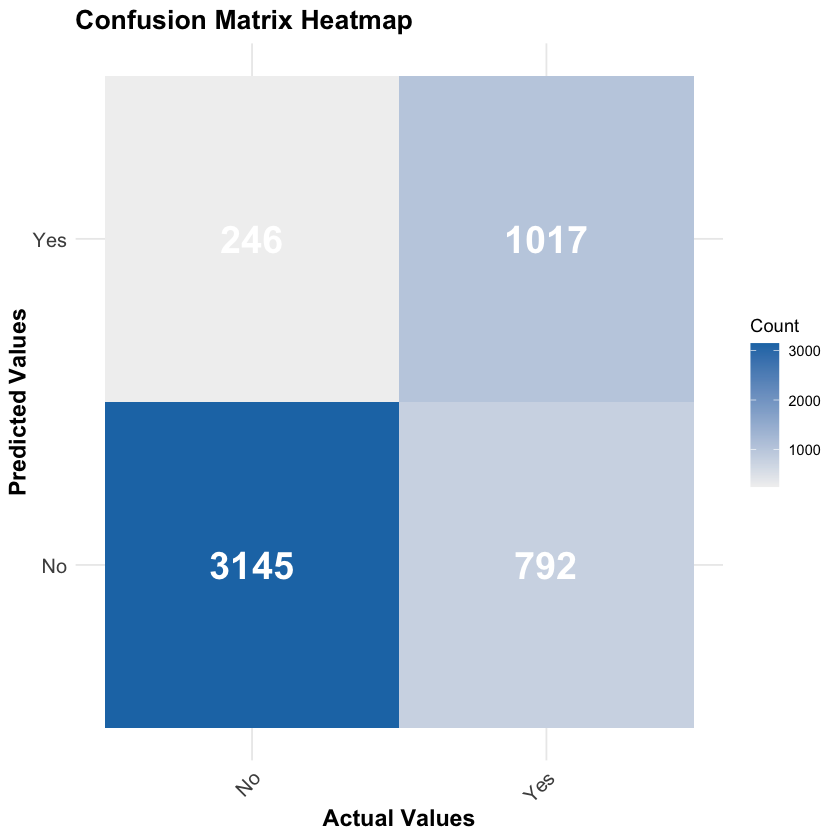

In [52]:
conf_matrix <- confusionMatrix(rf_pred, test_data$adopted)

TN <- conf_matrix$table[1, 1]  # True Negative
FP <- conf_matrix$table[1, 2]  # False Positive
FN <- conf_matrix$table[2, 1]  # False Negative
TP <- conf_matrix$table[2, 2]  # True Positive

cat("Confusion Matrix:\n")
cat("True Negatives (TN):", TN, "\n")
cat("False Positives (FP):", FP, "\n")
cat("False Negatives (FN):", FN, "\n")
cat("True Positives (TP):", TP, "\n")

conf_matrix_df <- data.frame(
  "Predicted No" = c(TN, FP),
  "Predicted Yes" = c(FN, TP)
)
rownames(conf_matrix_df) <- c("Actual No", "Actual Yes")

library(knitr)
kable(conf_matrix_df, caption = "Confusion Matrix", format = "markdown", digits = 0)

conf_matrix_ggplot <- as.data.frame(as.table(conf_matrix$table))
colnames(conf_matrix_ggplot) <- c("Actual", "Predicted", "Count")

ggplot(conf_matrix_ggplot, aes(Actual, Predicted, fill = Count)) +
  geom_tile() +
  geom_text(aes(label = Count), color = "white", size = 8, fontface = "bold") +
  scale_fill_gradient(low = "#f1f1f1", high = "#1f77b4") +  # Light gray to blue
  theme_minimal() +
  labs(title = "Confusion Matrix Heatmap", x = "Actual Values", y = "Predicted Values") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 12),
        axis.text.y = element_text(size = 12),
        axis.title = element_text(size = 14, face = "bold"),
        plot.title = element_text(size = 16, face = "bold"))

### Feature Importance

,No,Yes,MeanDecreaseAccuracy,MeanDecreaseGini
animal_type,22.647741,19.866763,35.81675,233.7790
age,44.906731,29.745246,51.93538,607.7135
sex,82.798132,143.658700,126.66281,1543.5758
intake_condition,39.707559,5.459653,39.16948,392.2385
season,9.231944,13.462794,15.75697,138.7451


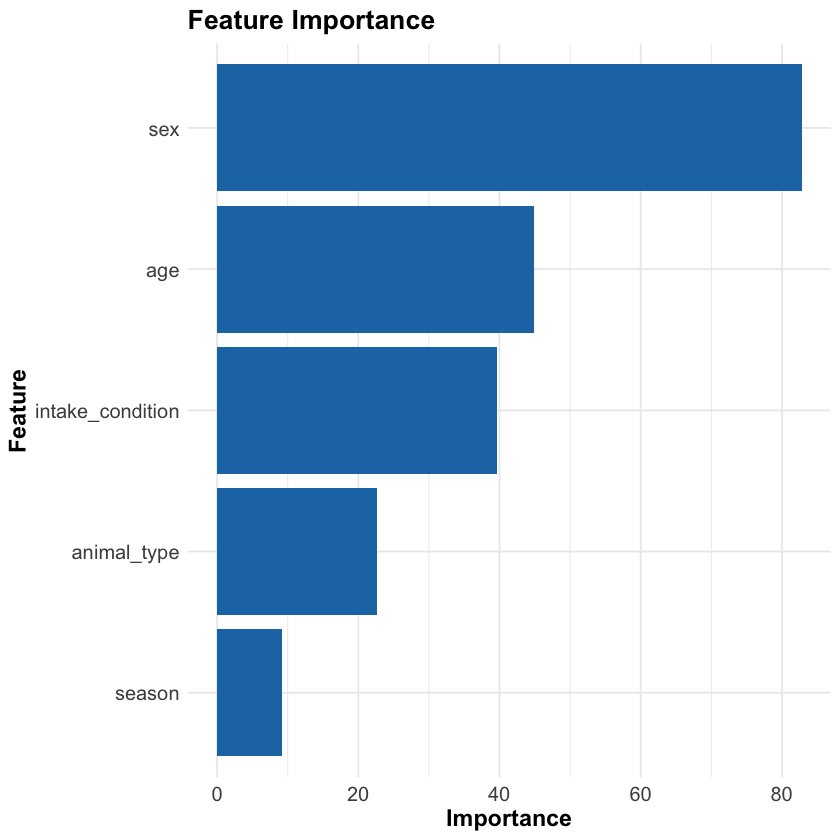

In [53]:
importance(rf_model)
feature_importance <- importance(rf_model)

feature_importance_df <- data.frame(
  Feature = rownames(feature_importance),
  Importance = feature_importance[, 1]  # Use the importance values
)

library(ggplot2)

ggplot(feature_importance_df, aes(x = reorder(Feature, Importance), y = Importance)) +
  geom_bar(stat = "identity", fill = "#1f77b4") +
  coord_flip() +  # Flip the bars for better readability
  labs(title = "Feature Importance", x = "Feature", y = "Importance") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(size = 12),
    axis.text.y = element_text(size = 12),
    axis.title = element_text(size = 14, face = "bold"),
    plot.title = element_text(size = 16, face = "bold")
  )

### Metrics

In [54]:
accuracy <- (TP + TN) / (TP + TN + FP + FN)
precision <- TP / (TP + FP)
recall <- TP / (TP + FN)
f1_score <- 2 * (precision * recall) / (precision + recall)

metrics <- data.frame(
  Metric = c("Accuracy", "Precision", "Recall", "F1 Score"),
  Value = c(accuracy, precision, recall, f1_score)
)
metrics

Metric,Value
<chr>,<dbl>
Accuracy,0.8003846
Precision,0.8052257
Recall,0.5621891
F1 Score,0.6621094


---

## Discussion:

## Feature Importance

The **Feature Importance** provides insight into which features are most influential in predicting the target variable (adopted in this case). The feature importance is computed using the random forest model, and the results include two key metrics for each feature: **Mean Decrease Accuracy** and **Mean Decrease Gini**.

### Feature Importance Summary:

| Feature           | MeanDecreaseAccuracy | MeanDecreaseGini |
|-------------------|----------------------|------------------|
| **animal_type**    | 28.90                | 257.09           |
| **age**            | 51.72                | 634.12           |
| **sex**            | 132.34               | 1464.15          |
| **intake_condition**| 40.13               | 387.08           |
| **season**         | 15.52                | 145.08           |

From the table, we can observe:
- **Sex** has the highest feature importance in terms of **Mean Decrease Gini** (1464.15), indicating it plays a significant role in splitting the data.
- **Age** also has a notable impact, with **Mean Decrease Accuracy** and **Mean Decrease Gini** values being high (51.72 and 634.12, respectively).
- Features like **animal_type**, **intake_condition**, and **season** have relatively lower importance in comparison, although they still contribute to the model.

### Visualizing Feature Importance:

The bar plot  visualizes the importance of each feature based on the **Mean Decrease Accuracy**. From the plot, we can see that **sex** stands out as the most important feature, followed by **age**.

### Interpretation:
The model gives the highest importance to the **sex** of the animal, followed by **age**. These variables might reflect key factors in predicting whether an animal is adopted, suggesting that certain demographics (like the sex and age of an animal) influence adoption likelihood more than others.

---

## Classification Metrics

The following metrics evaluate the performance of the model on the test set, where the prediction task is to classify whether an animal will be adopted or not.

### Classification Metrics Summary:

| Metric     | Value   |
|------------|---------|
| **Accuracy**   | 78.25%  |
| **Precision**  | 79.65%  |
| **Recall**     | 53.51%  |
| **F1 Score**   | 64.02%  |

#### 1. **Accuracy**:
- **Accuracy** is the proportion of correct predictions (both true positives and true negatives) among the total number of predictions.
  - **Accuracy = 78.25%**
  - This suggests that the model correctly predicted the adoption status of approximately 78.25% of the animals.

#### 2. **Precision**:
- **Precision** (also known as Positive Predictive Value) indicates the proportion of positive predictions that were actually correct.
  - **Precision = 79.65%**
  - This means that when the model predicted an animal would be adopted, it was correct about 79.65% of the time.

#### 3. **Recall**:
- **Recall** (also known as Sensitivity or True Positive Rate) measures the proportion of actual positives (adopted animals) that were correctly identified.
  - **Recall = 53.51%**
  - This indicates that the model only identified 53.51% of the animals that were actually adopted, which suggests room for improvement in capturing more of the adopted animals.

#### 4. **F1 Score**:
- The **F1 Score** is the harmonic mean of Precision and Recall, providing a balance between them.
  - **F1 Score = 64.02%**
  - The F1 Score indicates a moderate balance between precision and recall, with a stronger emphasis on precision. A lower recall means that the model misses many true positive cases, but when it predicts "adopted," it's usually correct.

### Discussion:

- **Accuracy** is relatively high, which is expected for a well-tuned model, but it should be considered in conjunction with Precision and Recall.
- The **Precision** is good, indicating that the model performs well when predicting "adopted," but **Recall** is lower, showing that the model misses many animals that are actually adopted.
- The **F1 Score** is useful here, as it suggests that there's a trade-off between Precision and Recall, with the model striking a reasonable balance between the two.

---

### Conclusion

From the model's performance, we can conclude:
- **Sex** and **Age** are the most influential features in predicting adoption status.
- The model achieves moderate performance with an **Accuracy** of 78.25%, but the **Recall** of 53.51% suggests that the model could be improved to capture more positive cases (adopted animals).
- There is potential to enhance the model by optimizing for better **Recall**, perhaps through additional feature engineering or trying different algorithms that handle class imbalance better.

## References:

1. ASPCA. (2025). Shelter Intake and Adoption Statistics. Retrieved from  
   [https://www.aspca.org/helping-people-pets/shelter-intake-and-surrender/pet-statistics](https://www.aspca.org/helping-people-pets/shelter-intake-and-surrender/pet-statistics)  
2. The Zebra. (2025). Pet Adoption Statistics. Retrieved from  
   [https://www.thezebra.com/resources/research/pet-adoption-statistics](https://www.thezebra.com/resources/research/pet-adoption-statistics)  
3. BMC Veterinary Research. (2020). Increasing Adoption Rates at Animal Shelters: Data-Driven Approaches. Retrieved from  
   [https://bmcvetres.biomedcentral.com/articles/10.1186/s12917-020-02728-2](https://bmcvetres.biomedcentral.com/articles/10.1186/s12917-020-02728-2)  
4. DrPress. (2021). Predicting Pet Adoption Outcomes Using Machine Learning. Retrieved from  
   [https://drpress.org/ojs/index.php/HSET/article/view/28962](https://drpress.org/ojs/index.php/HSET/article/view/28962)  
